Affordability stress does not reliably predict housing downturns,
but conditional on downturns, higher DTI growth is associated with
materially worse mortgage delinquency outcomes.

In [1]:
import pandas as pd
import numpy as np
from pandas_datareader import data as pdr

start = "1995-01-01"
end = None

delinq = pdr.DataReader("DRSFRMACBS", "fred", start, end)
delinq = delinq.rename(columns={"DRSFRMACBS": "delinq_rate"})
delinq = delinq.resample("Q").last().reset_index()

delinq.head()

/var/folders/dg/2kv5bj0j5d9c8wklbylhzg800000gn/T/ipykernel_40668/3993226113.py:10: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  delinq = delinq.resample("Q").last().reset_index()


,DATE,delinq_rate
0,1995-03-31,2.08
1,1995-06-30,2.11
2,1995-09-30,2.16
3,1995-12-31,2.17
4,1996-03-31,2.18


In [2]:
df = pd.read_csv("../data/processed/phase1_main.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

In [3]:
df["delta_dti_yoy"] = df["dti"] - df["dti"].shift(4)


In [5]:
print(delinq.head())
print(delinq.columns)
print(type(delinq.index))

        DATE  delinq_rate
0 1995-03-31         2.08
1 1995-06-30         2.11
2 1995-09-30         2.16
3 1995-12-31         2.17
4 1996-03-31         2.18
Index(['DATE', 'delinq_rate'], dtype='object')
<class 'pandas.core.indexes.range.RangeIndex'>


In [8]:
delinq = delinq.rename(columns={"DATE": "date"})
delinq["date"] = pd.to_datetime(delinq["date"])

In [9]:
df["date"] = pd.to_datetime(df["date"])

In [10]:
df["date"] = pd.to_datetime(df["date"]).dt.to_period("Q").dt.to_timestamp("Q")

In [11]:
df2 = df.merge(delinq, on="date", how="inner")
df2.shape
df2[["date", "dti", "delta_dti_yoy", "delinq_rate"]].dropna().head()

,date,dti,delta_dti_yoy,delinq_rate
4,2000-03-31,88.622364,5.489599,1.95
5,2000-06-30,83.972544,-7.102018,1.98
6,2000-09-30,88.781469,4.710639,2.09
7,2000-12-31,88.873529,3.095285,2.23
8,2001-03-31,87.695195,-0.927169,2.34


In [13]:
print("df date range:", df["date"].min(), df["date"].max(), "n=", len(df))
print("delinq date range:", delinq["date"].min(), delinq["date"].max(), "n=", len(delinq))
print("merged n=", len(df2))

df date range: 1999-03-31 00:00:00 2024-12-31 00:00:00 n= 104
delinq date range: 1995-03-31 00:00:00 2025-09-30 00:00:00 n= 123
merged n= 104


In [14]:
df2["covid_dummy"] = ((df2["date"] >= "2020-10-01") & (df2["date"] <= "2022-06-30")).astype(int)

DOWN_REGIME = 1  # real_rate < 0

df_main = df2[(df2["covid_dummy"] == 0) & (df2["regime"] == DOWN_REGIME)].copy()

len(df_main)

45

In [15]:
hi = df_main["delta_dti_yoy"].quantile(0.7)
lo = df_main["delta_dti_yoy"].quantile(0.3)

df_main["stress_group"] = np.nan
df_main.loc[df_main["delta_dti_yoy"] >= hi, "stress_group"] = "High ΔDTI"
df_main.loc[df_main["delta_dti_yoy"] <= lo, "stress_group"] = "Low ΔDTI"

df_plot = df_main.dropna(subset=["stress_group"]).copy()
df_plot["stress_group"].value_counts()

/var/folders/dg/2kv5bj0j5d9c8wklbylhzg800000gn/T/ipykernel_40668/1973432722.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'High ΔDTI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_main.loc[df_main["delta_dti_yoy"] >= hi, "stress_group"] = "High ΔDTI"


stress_group
High ΔDTI    13
Low ΔDTI     13
Name: count, dtype: int64

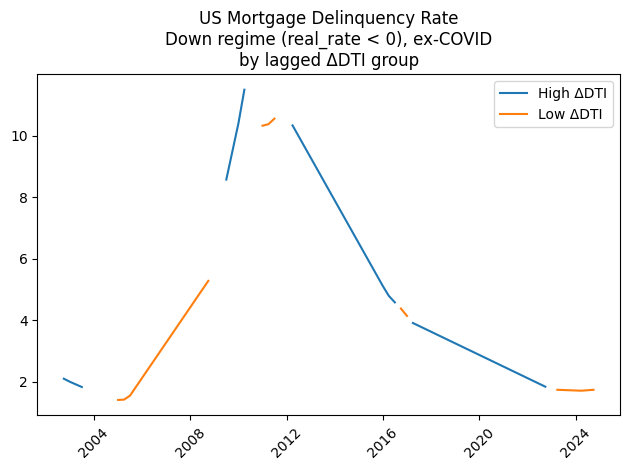

In [21]:
plt.figure()
plt.plot(g.index, g["High ΔDTI"], label="High ΔDTI")
plt.plot(g.index, g["Low ΔDTI"], label="Low ΔDTI")
plt.title(
    "US Mortgage Delinquency Rate\n"
    "Down regime (real_rate < 0), ex-COVID\n"
    "by lagged ΔDTI group"
)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

import os
os.makedirs("reports", exist_ok=True)
plt.savefig("reports/phase2B_us_delinquency.png", dpi=200, bbox_inches="tight")

plt.show()


In [23]:
raise SystemExit("stop after main figure")


SystemExit: stop after main figure

/Users/axl/Mispricing Model_Leviathan/leviathan-model/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [22]:
import os
import matplotlib.pyplot as plt

g = (
    df_plot
    .groupby(["date", "stress_group"])["delinq_rate"]
    .mean()
    .unstack()
)

# 防止 g 没东西
print("g shape:", g.shape)
print(g.tail())
assert g.shape[0] > 0, "g is empty (no rows) — check filters/merge"

os.makedirs("reports", exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(g.index, g["High ΔDTI"], label="High ΔDTI")
ax.plot(g.index, g["Low ΔDTI"], label="Low ΔDTI")

ax.set_title(
    "US Mortgage Delinquency Rate\n"
    "Down regime (real_rate < 0), ex-COVID\n"
    "by lagged ΔDTI group"
)
ax.tick_params(axis="x", rotation=45)
ax.legend()
ax.grid(True, alpha=0.2)

fig.tight_layout()
fig.savefig("reports/phase2B_us_delinquency.png", dpi=220, bbox_inches="tight")
plt.close(fig)

print("saved: reports/phase2B_us_delinquency.png")


g shape: (26, 2)
stress_group  High ΔDTI  Low ΔDTI
date                             
2017-03-31         3.91       NaN
2022-09-30         1.84       NaN
2023-03-31          NaN      1.74
2024-03-31          NaN      1.71
2024-09-30          NaN      1.74
saved: reports/phase2B_us_delinquency.png


In [24]:
print("non-null counts:\n", g.notna().sum())
print("y range:", g.min().min(), g.max().max())


non-null counts:
 stress_group
High ΔDTI    13
Low ΔDTI     13
dtype: int64
y range: 1.41 11.49


In [25]:
hi_s = g["High ΔDTI"].dropna()
lo_s = g["Low ΔDTI"].dropna()

print("High points:", len(hi_s), "Low points:", len(lo_s))
assert len(hi_s) > 0 or len(lo_s) > 0, "Both series empty after dropna."

ax.plot(hi_s.index, hi_s.values, marker="o", linewidth=2, label="High ΔDTI")
ax.plot(lo_s.index, lo_s.values, marker="o", linewidth=2, label="Low ΔDTI")

# y轴给点 padding，避免自动缩放怪异
ymin = min(hi_s.min() if len(hi_s) else np.inf, lo_s.min() if len(lo_s) else np.inf)
ymax = max(hi_s.max() if len(hi_s) else -np.inf, lo_s.max() if len(lo_s) else -np.inf)
ax.set_ylim(ymin - 0.25, ymax + 0.25)


High points: 13 Low points: 13


(1.16, 11.74)